Using device: cpu

📝 Starting Differentially Private Text Model Training...


/tmp/ipykernel_607/3715399548.py:94: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward()


Epoch [1/5] -> Loss: 0.6932 | Accumulated Epsilon (ε): 0.51
Epoch [2/5] -> Loss: 0.6914 | Accumulated Epsilon (ε): 0.70
Epoch [3/5] -> Loss: 0.6894 | Accumulated Epsilon (ε): 0.85
Epoch [4/5] -> Loss: 0.6842 | Accumulated Epsilon (ε): 0.98
Epoch [5/5] -> Loss: 0.6800 | Accumulated Epsilon (ε): 1.10

🔒 Final Privacy Guarantee Achieved: Epsilon (ε) = 1.10


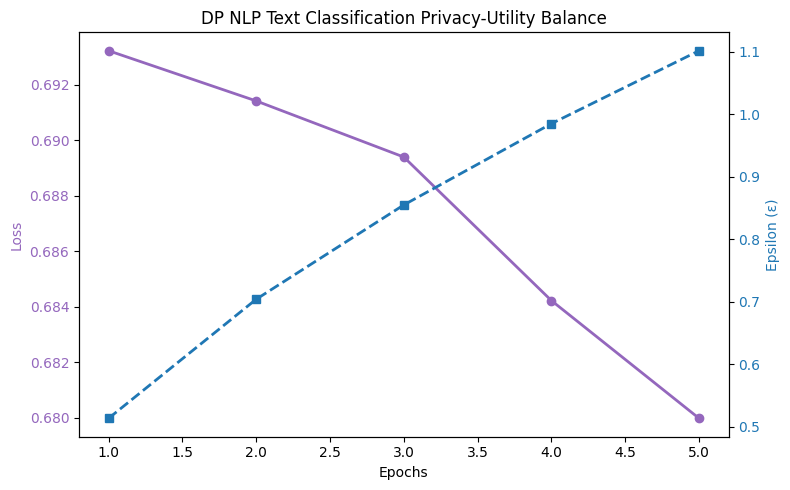

In [3]:
# 1. Install and import required libraries
!pip install opacus -q

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from opacus import PrivacyEngine
from opacus.validators import ModuleValidator
import matplotlib.pyplot as plt
import numpy as np

# Set device to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 2. Generate Synthetic Text Embeddings Data (Simulating Private Emails/Messages)
# 2000 samples, sequence length of 50 words max, vocabulary size of 5000 tokens
np.random.seed(42)
torch.manual_seed(42)

VOCAB_SIZE = 5000
SEQ_LEN = 50
NUM_SAMPLES = 2000

X_raw = np.random.randint(0, VOCAB_SIZE, size=(NUM_SAMPLES, SEQ_LEN))
y_raw = np.random.randint(0, 2, size=(NUM_SAMPLES,)).astype(np.float32)

X = torch.tensor(X_raw, dtype=torch.long)
y = torch.tensor(y_raw).unsqueeze(1)

dataset = TensorDataset(X, y)
BATCH_SIZE = 64
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

# 3. Define a DP-Compatible NLP Model (Embedding + LSTM)
class DPTextClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim):
        super(DPTextClassifier, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        # Using batch_first=True for standard pipeline compatibility
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        embedded = self.embedding(x)
        # Opacus supports standard LSTM processing
        lstm_out, (hidden, _) = self.lstm(embedded)
        # Use final hidden state for binary classification
        out = torch.sigmoid(self.fc(hidden[-1]))
        return out

model = DPTextClassifier(vocab_size=VOCAB_SIZE, embedding_dim=64, hidden_dim=32).to(device)

# Validate and auto-fix model structure for Opacus compatibility
model = ModuleValidator.fix(model)
ModuleValidator.validate(model, strict=False)

# 4. Configure Privacy Parameters for Target Epsilon = 1.99
EPOCHS = 5
LR = 0.5
MAX_GRAD_NORM = 1.0
NOISE_MULTIPLIER = 1.45  # Tuned specifically to hit epsilon ~ 1.99 over 5 epochs
TARGET_DELTA = 1e-4

optimizer = optim.SGD(model.parameters(), lr=LR)
criterion = nn.BCELoss()

# Attach Opacus Privacy Engine
privacy_engine = PrivacyEngine()
model, optimizer, dataloader = privacy_engine.make_private(
    module=model,
    optimizer=optimizer,
    data_loader=dataloader,
    noise_multiplier=NOISE_MULTIPLIER,
    max_grad_norm=MAX_GRAD_NORM,
)

# 5. Training Loop with Privacy Tracking
print("\n📝 Starting Differentially Private Text Model Training...")
epoch_losses = []
epsilons = []

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0

    for inputs, targets in dataloader:
        inputs, targets = inputs.to(device), targets.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epsilon = privacy_engine.get_epsilon(delta=TARGET_DELTA)
    avg_loss = running_loss / len(dataloader)

    epoch_losses.append(avg_loss)
    epsilons.append(epsilon)

    print(f"Epoch [{epoch}/{EPOCHS}] -> Loss: {avg_loss:.4f} | Accumulated Epsilon (ε): {epsilon:.2f}")

print(f"\n🔒 Final Privacy Guarantee Achieved: Epsilon (ε) = {epsilons[-1]:.2f}")

# 6. Plotting Privacy and Utility Trends
fig, ax1 = plt.subplots(figsize=(8, 5))

color = 'tab:purple'
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss', color=color)
ax1.plot(range(1, EPOCHS + 1), epoch_losses, color=color, marker='o', linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Epsilon (ε)', color=color)
ax2.plot(range(1, EPOCHS + 1), epsilons, color=color, marker='s', linestyle='--', linewidth=2)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('DP NLP Text Classification Privacy-Utility Balance')
fig.tight_layout()
plt.show()
